In [ ]:
import os

USER_PATH = '${USER_PATH}/'
DATA_PATH = 'E-COMP - mocodo'

path = os.path.join(os.path.expanduser(USER_PATH), DATA_PATH)


os.listdir(path)

['scenarios_wrevenues.csv',
 'scenarios_wrevenues_subset.csv',
 'design_solutions.csv',
 'design_solutions_v0.csv',
 'scenarios.csv',
 'MoCoDo formulation.docx',
 'design_solutions_per_scenario.csv']

In [2]:
import pandas as pd

df_design = pd.read_csv(os.path.join(path, 'design_solutions_v0.csv'), index_col=0)\
    .drop(columns=['Reserve ESS Revenue ($k)'])

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


\begin{tabular}{llllllll}
\toprule
 & $r_1$ & $r_2$ & $r_3$ & $r_4$ & $r_5$ & $g$ & notes \\
$i$ &  &  &  &  &  &  &  \\
\midrule
1 & 6 & 4 & 2 & 4 & 7 & 7 & $\leftarrow \textit{most generalizable}$ \\
2 & \cir{4} & \sqr{5} & \sqr{4} & \sqr{8} & \cir{5} & 8,5 &  \\
3 & \cir{2} & \cir{3} & \sqr{7} & 7 & \sqr{8} & 8,7 &  \\
4 & \cir{1} & \sqr{8} & \sqr{8} & 5 & \cir{3} & 8,8 &  \\
5 & 5 & \sqr{9} & 3 & \cir{2} & \cir{2} & 9,5 & $\leftarrow \textit{example tradeoff}$ \\
6 & \sqr{9} & 6 & \cir{1} & 3 & 6 & 9,6 &  \\
7 & 8 & 7 & \sqr{9} & 6 & 4 & 9,8 & $\leftarrow \textit{no specialization}$ \\
8 & 7 & \cir{2} & 5 & \sqr{9} & \sqr{9} & 9,9 &  \\
9 & 3 & \cir{1} & 6 & \sqr{10} & \sqr{10} & 10,10,6 &  \\
10 & \sqr{10} & \sqr{10} & \sqr{10} & \cir{1} & \cir{1} & 10,10,10 & $\leftarrow \textit{least generalizable}$ \\
\bottomrule
\end{tabular}



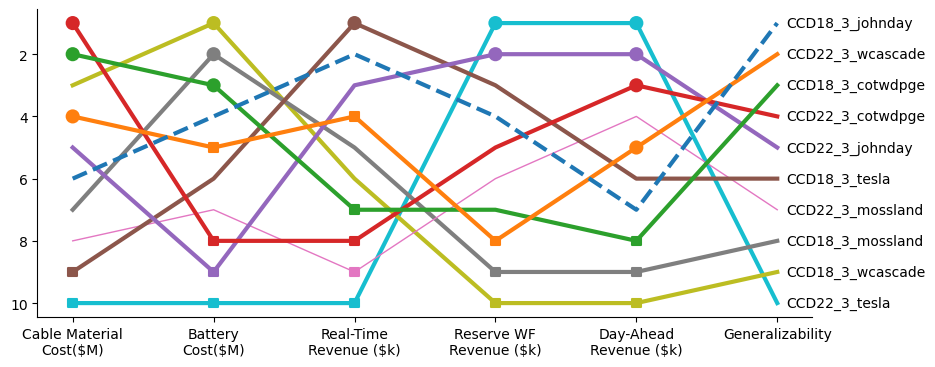

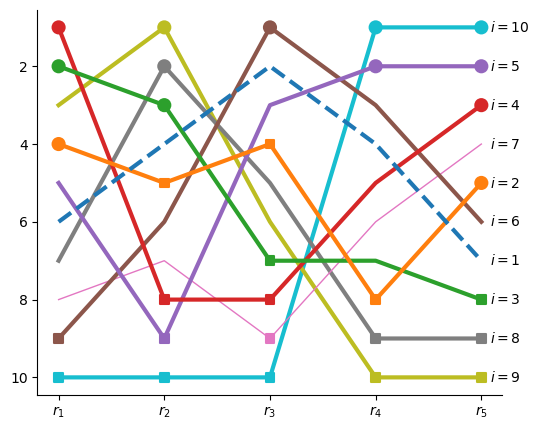

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from importlib import reload
import tradeoff_lattice as tl; reload(tl)

ovars = [
    c
    for c in df_design.columns
    if '$' in c
]

def ovar_format(s):
    sep = ' Revenue'
    if ' Cost' in s:
        sep = ' Cost'

    left, right = s.split(sep)
    return f'{left}\n{sep[1:]}{right}'

def sol_format(s):
    all = s.split('_')
    left = ' '.join(all[:-1])
    right = all[-1]
    return f'{left}\n{right}'
    
xlabels = {
    s: ovar_format(s)
    for s in ovars
}

ylabels = {
    s: sol_format(s)
    for s in df_design.index
}
    
ascending = [
    c
    for c in ovars
    if 'Cost' in c
]

dvars = set(df_design.columns).difference(ovars)

def create_tradeoff_lattice():
    reload(tl)
    return tl.TradeoffLattice(
        df_design, ovars, dvars,
        ascending=ascending
    )
    
self = create_tradeoff_lattice()

plt.figure(figsize=(10, 4))
self.plot_pcp(
    x_labels=xlabels,
    # show_tradeoff=False, # uncomment to make squares not visible
    # show_generalizability_as=None # uncomment to hide the "Generalizability" column
)

rows = np.arange(len(self.rank.index)) + 1
cols = np.arange(len(self.rank.columns)) + 1

xticklabels = pd.Series([f'$r_{c}$' for c in cols], index=self.rank.columns)
yticklabels = pd.Series([f'$i = {r}$' for r in rows], index=self.rank.index)

plt.figure(figsize=(6, 5))
self.plot_pcp(
    x_labels=xticklabels.to_dict(),
    labels=yticklabels.to_dict(),
    # show_tradeoff=False, # uncomment to make squares not visible
    show_generalizability_as=None # uncomment to hide the "Generalizability" column
)

# plt.title('Parallel Coordinates Plot of Ranks')

plt.savefig('pcp-example.pdf', format='pdf', bbox_inches='tight')

index = pd.Index(rows, name='$i$')
notes = pd.Series(index=index, dtype=str)
notes[1] = '$\\leftarrow \\textit{most generalizable}$'
notes[5] = '$\\leftarrow \\textit{example tradeoff}$'
notes[7] = '$\\leftarrow \\textit{no specialization}$'
notes[10] = '$\\leftarrow \\textit{least generalizable}$'

print(self.to_latex(
    index=index,
    columns=xticklabels,
    notes=notes
))

In [4]:
self.specialization_and_tradeoff

,Cable Material Cost($M),Battery Cost($M),Real-Time Revenue ($k),Reserve WF Revenue ($k),Day-Ahead Revenue ($k)
CCD18_3_cotwdpge,1,1,-1,0,-1
CCD18_3_mossland,0,1,0,-1,-1
CCD18_3_tesla,-1,0,1,0,0
CCD18_3_wcascade,0,1,0,-1,-1
CCD22_3_cotwdpge,1,-1,-1,0,1
CCD22_3_johnday,0,-1,0,1,1
CCD22_3_mossland,0,0,-1,0,0
CCD22_3_tesla,-1,-1,-1,1,1
CCD22_3_wcascade,1,-1,-1,-1,1


# we can also use the old threshold-based approach by specifying a k
# If we do this, then any rank above all generalizers is considered a specializer

self = create_tradeoff_lattice()

k = 2

plt.figure(figsize=(10, 4))
self.plot_pcp(
    x_labels=xlabels,
    specialization=self.specialization_at_k(k),
    generalizers=self.rank.index[:k],
)


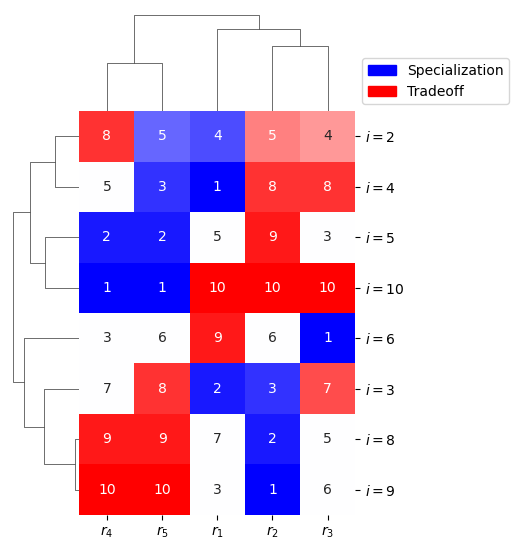

In [5]:
cm = create_tradeoff_lattice()\
    .plot_heatmap(
        figsize=(4, 5.6),
        xticklabels=xticklabels,
        yticklabels=yticklabels[self.specialization.index],
        # row_cluster=False, # comment to show dendrogram on rows
        # col_cluster=False # comment to show dendrogram on cols
        # show_ranks=False
    )

plt.sca(cm.ax_heatmap)
plt.yticks(rotation=0)

plt.savefig('heatmap-example.pdf', format='pdf', bbox_inches='tight')

In [6]:
self.df

,Cable Capacity(MW),Battery Rated Power(MW),Cable Material Cost($M),Battery Cost($M),Day-Ahead Revenue ($k),Real-Time Revenue ($k),Reserve WF Revenue ($k)
CCD18_3_cotwdpge,1991.029248,54.300003,200.495302,48.276124,1087.482856,19.060969,0.512244
CCD18_3_johnday,2585.009992,70.499999,356.846697,62.678940,1360.725359,33.620576,0.651006
CCD18_3_mossland,1980.003137,53.999993,406.362990,48.009396,960.079498,20.165528,0.456483
CCD18_3_tesla,2904.001129,79.200000,544.461908,70.413789,1482.503741,39.052081,0.712933
CCD18_3_wcascade,1650.006081,45.000000,279.352643,40.007835,914.059737,19.081562,0.420015
CCD22_3_cotwdpge,1991.023489,90.499991,200.494722,80.460193,2534.572056,13.476278,0.603545
CCD22_3_johnday,2585.003001,117.500000,356.845731,104.464902,3006.659806,23.054879,0.724474
CCD22_3_mossland,1980.046451,89.999778,406.371879,80.015473,2106.973029,10.515738,0.533402
CCD22_3_tesla,2904.004155,131.999982,544.462475,117.356300,3375.905789,7.844127,0.891775
CCD22_3_wcascade,1650.006875,75.000000,279.352777,66.679725,2099.266635,20.578652,0.471774


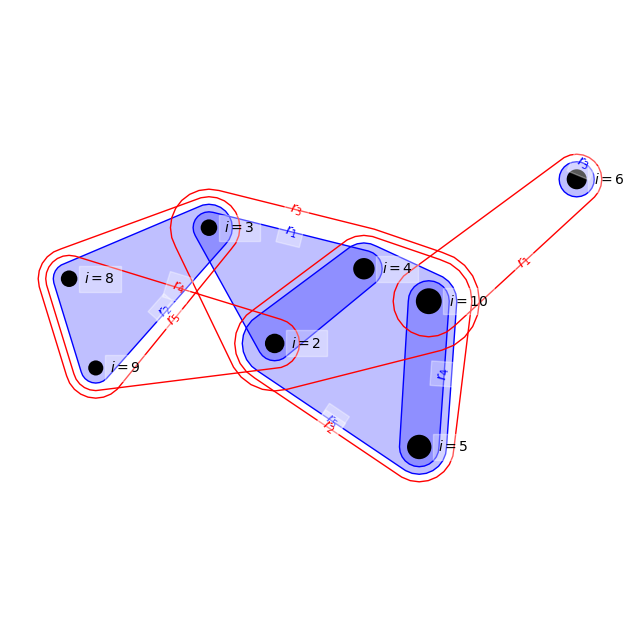

In [7]:
import networkx as nx
reload(tl)

tl.TradeoffLattice.plot_specializers_and_tradeoff_as_hypergraph(self,
    edge_labels=xticklabels,
    node_labels=yticklabels,
    layout=nx.nx_agraph.graphviz_layout,
    node_size_by='Battery Rated Power(MW)',
    # node_color_by='Battery Rated Power(MW)', # possibly leave this commented out--color on nodes is clashy with edge colors
    smin=0,
)

# color or size dots according to a feature in the dataset

plt.savefig('specializer-tradeoff-euler.pdf', format='pdf', bbox_inches='tight')

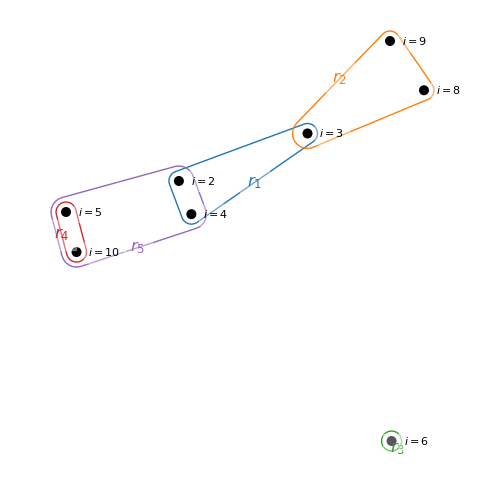

In [8]:
self = create_tradeoff_lattice()

kwargs = dict(
    # fill_edges=True,
    node_labels=yticklabels,
    edge_labels=xticklabels
)

plt.figure(figsize=(6, 6))
pos = self.plot_hypergraph_euler(
    return_pos=True,
    node_labels_kwargs=dict(fontsize=8),
    edge_labels_kwargs=dict(fontsize=12, rotation=0),
    **kwargs
)

plt.savefig('euler-example.pdf', format='pdf', bbox_inches='tight')

CCD18_3_wcascade     45.000000
CCD18_3_mossland     53.999993
CCD18_3_cotwdpge     54.300003
CCD22_3_wcascade     75.000000
CCD18_3_tesla        79.200000
CCD22_3_cotwdpge     90.499991
CCD22_3_johnday     117.500000
CCD22_3_tesla       131.999982
Name: Battery Rated Power(MW), dtype: float64

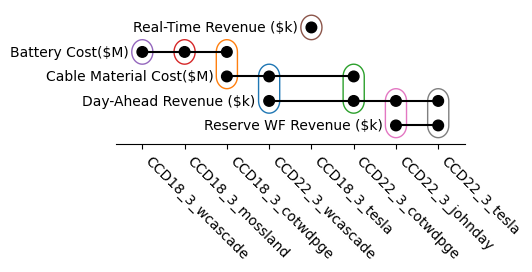

In [9]:
order_by = 'Battery Rated Power(MW)'

order = df_design.loc[self.specialization.index, order_by]\
    .sort_values()\
    .index

create_tradeoff_lattice()\
    .plot_hypergraph_upset(order=order)

df_design.loc[order, order_by]

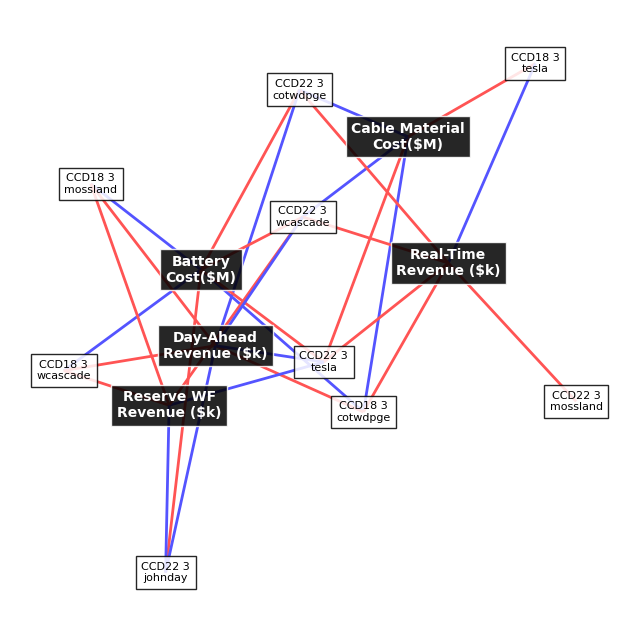

In [10]:
create_tradeoff_lattice()\
    .plot_tradeoff_lattice(
        labels={**xlabels, **ylabels}, 
        layout=tl.nx.kamada_kawai_layout
        # layout_kwargs=dict(prog='neato')
    )